In [1]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

img_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root='D:\\ML-research\\Datasets\\chest_xray_images\\train', transform=train_transform)
val_data = datasets.ImageFolder(root='D:\\ML-research\\Datasets\\chest_xray_images\\val', transform=val_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

print(f"-- Train samples: {len(train_data)}, Val samples: {len(val_data)}")

-- Train samples: 5580, Val samples: 798


In [2]:
import torch
from resformer import ResFormer  # Assuming resformer.py contains the ResFormer class
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResFormer(num_classes=3).to(device)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

print("-- Model loaded and moved to:", device)

-- Model loaded and moved to: cpu


In [3]:
# Training and Validation Loop
from tqdm import tqdm
import torch.nn.functional as F

def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    from sklearn.metrics import classification_report, confusion_matrix
    print("\n-- Classification Report:\n", classification_report(all_labels, all_preds, target_names=['Normal', 'Bacterial', 'Viral']))
    print("-- Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
    return 100. * correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):
    best_acc = 0
    train_acc_list, val_acc_list, loss_list = [], [], []
    for epoch in range(num_epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0
        loop = tqdm(train_loader, leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()
            loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
            loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

        scheduler.step()
        train_acc = 100.*correct/total
        val_acc = evaluate_model(model, val_loader)

        if val_acc > best_acc:
            best_acc = val_acc
            
            torch.save(model.state_dict(), "D:\\ML-research\\Datasets\\chest_xray_images\\Model\\best_resformer-8.pth")
            print(f"-- Epoch {epoch+1}: New best model saved with Val Acc: {val_acc:.2f}%")

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(running_loss / len(train_loader))

        print(f"--> Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Loss: {running_loss/len(train_loader):.4f}")

    return train_acc_list, val_acc_list, loss_list


In [4]:
# Plot Training Results
import matplotlib.pyplot as plt

def plot_graphs(train_acc_list, val_acc_list, loss_list):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_acc_list, label='Train Acc')
    plt.plot(val_acc_list, label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(loss_list, label='Train Loss')
    plt.title('Loss over Epochs')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()


  0%|          | 0/175 [00:00<?, ?it/s]


-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.83      0.71      0.77       278
   Bacterial       0.84      0.96      0.89       259
       Viral       0.72      0.73      0.72       261

    accuracy                           0.80       798
   macro avg       0.80      0.80      0.80       798
weighted avg       0.80      0.80      0.79       798

-- Confusion Matrix:
 [[197  15  66]
 [  2 248   9]
 [ 37  33 191]]
-- Epoch 1: New best model saved with Val Acc: 79.70%
--> Epoch 1: Train Acc: 67.72%, Val Acc: 79.70%, Loss: 0.8202



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.90      0.65      0.75       278
   Bacterial       0.90      0.97      0.93       259
       Viral       0.68      0.83      0.75       261

    accuracy                           0.81       798
   macro avg       0.83      0.81      0.81       798
weighted avg       0.83      0.81      0.81       798

-- Confusion Matrix:
 [[180   4  94]
 [  1 250   8]
 [ 20  24 217]]
-- Epoch 2: New best model saved with Val Acc: 81.08%
--> Epoch 2: Train Acc: 77.01%, Val Acc: 81.08%, Loss: 0.6934



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.80      0.86      0.83       278
   Bacterial       0.92      0.97      0.94       259
       Viral       0.81      0.70      0.75       261

    accuracy                           0.84       798
   macro avg       0.84      0.84      0.84       798
weighted avg       0.84      0.84      0.84       798

-- Confusion Matrix:
 [[238   2  38]
 [  2 251   6]
 [ 58  21 182]]
-- Epoch 3: New best model saved with Val Acc: 84.09%
--> Epoch 3: Train Acc: 80.04%, Val Acc: 84.09%, Loss: 0.6445



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.89      0.69      0.78       278
   Bacterial       0.89      0.98      0.94       259
       Viral       0.73      0.82      0.77       261

    accuracy                           0.83       798
   macro avg       0.84      0.83      0.83       798
weighted avg       0.84      0.83      0.83       798

-- Confusion Matrix:
 [[193   8  77]
 [  0 255   4]
 [ 24  23 214]]
--> Epoch 4: Train Acc: 81.27%, Val Acc: 82.96%, Loss: 0.6255


...


-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.76      0.91      0.83       278
   Bacterial       0.93      0.98      0.95       259
       Viral       0.87      0.64      0.73       261

    accuracy                           0.84       798
   macro avg       0.85      0.84      0.84       798
weighted avg       0.85      0.84      0.84       798

-- Confusion Matrix:
 [[254   2  22]
 [  2 254   3]
 [ 77  18 166]]
--> Epoch 16: Train Acc: 84.16%, Val Acc: 84.46%, Loss: 0.5640



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.90      0.66      0.76       278
   Bacterial       0.85      0.99      0.91       259
       Viral       0.71      0.79      0.75       261

    accuracy                           0.81       798
   macro avg       0.82      0.81      0.81       798
weighted avg       0.82      0.81      0.81       798

-- Confusion Matrix:
 [[184  11  83]
 [  0 256   3]
 [ 20  34 207]]
--> Epoch 17: Train Acc: 83.94%, Val Acc: 81.08%, Loss: 0.5771



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.86      0.79      0.82       278
   Bacterial       0.81      1.00      0.90       259
       Viral       0.77      0.67      0.72       261

    accuracy                           0.82       798
   macro avg       0.81      0.82      0.81       798
weighted avg       0.82      0.82      0.81       798

-- Confusion Matrix:
 [[219   9  50]
 [  0 258   1]
 [ 37  50 174]]
--> Epoch 18: Train Acc: 83.71%, Val Acc: 81.58%, Loss: 0.5764



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.89      0.78      0.83       278
   Bacterial       0.96      0.97      0.97       259
       Viral       0.77      0.86      0.81       261

    accuracy                           0.87       798
   macro avg       0.87      0.87      0.87       798
weighted avg       0.87      0.87      0.87       798

-- Confusion Matrix:
 [[217   0  61]
 [  0 252   7]
 [ 27  10 224]]
--> Epoch 19: Train Acc: 83.64%, Val Acc: 86.84%, Loss: 0.5753



-- Classification Report:
               precision    recall  f1-score   support

      Normal       0.81      0.87      0.84       278
   Bacterial       0.99      0.90      0.94       259
       Viral       0.78      0.79      0.79       261

    accuracy                           0.85       798
   macro avg       0.86      0.85      0.85       798
weighted avg       0.86      0.85      0.85       798

-- Confusion Matrix:
 [[241   0  37]
 [  5 232  22]
 [ 51   3 207]]
--> Epoch 20: Train Acc: 83.91%, Val Acc: 85.21%, Loss: 0.5741


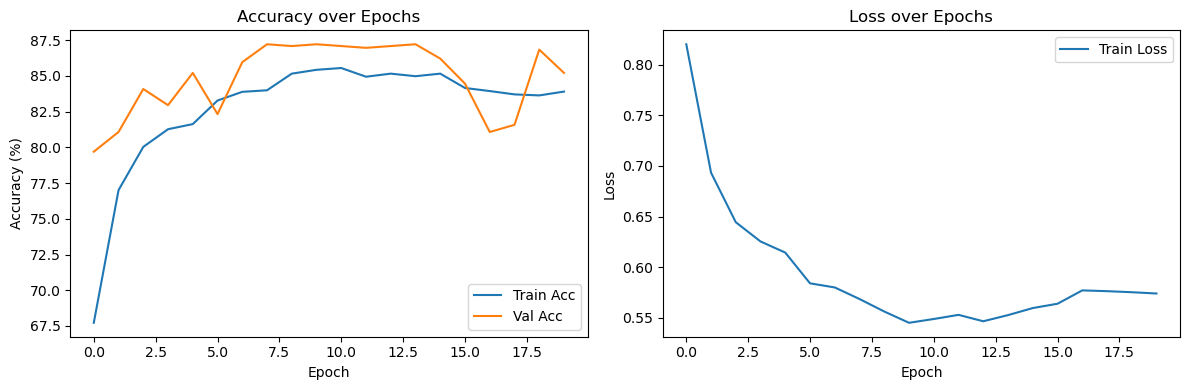

In [5]:
# Train Model
train_acc_list, val_acc_list, loss_list = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20
)
plot_graphs(train_acc_list, val_acc_list, loss_list)
